# Titanic Dataset Exploratory Data Analysis (EDA)

## Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Titanic dataset.

This project aims to:
- understand the structure of the dataset
- clean missing values
- analyze the target column
- study important features related to survival
- practice Python, NumPy, Pandas, Matplotlib, and Seaborn

This analysis will help in understanding passenger survival patterns and preparing for future machine learning tasks.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# Overview of Dataset 

In [7]:
# load titanic dataset
df = sns.load_dataset("titanic")

In [8]:
# view top 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
# checking rows and columns
df.shape

(891, 15)

In [15]:
# viewing all columns
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [16]:
# summary information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [17]:
# statistical summary of dataset
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# DATA CLEANING

In [20]:
# checking missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
# drop deck column
df.drop(columns=['deck'] , inplace=True)

In [27]:
# fill age column with median
df['age'].fillna(df['age'].median(), inplace=True)

/tmp/ipykernel_55/1187900456.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


In [28]:
# fill embarked with mode
df['embarked'].fillna(df['embarked'].mode() ,inplace=True)

/tmp/ipykernel_55/3808432064.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna(df['embarked'].mode() ,inplace=True)


In [39]:
# drop embarked column
df.drop(columns=["embark_town"] , inplace=True)

In [40]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

# TARGET ANALYSIS

In [43]:
# univarite analysis of survived column
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [44]:
df['survived'].value_counts(normalize=True) * 100

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

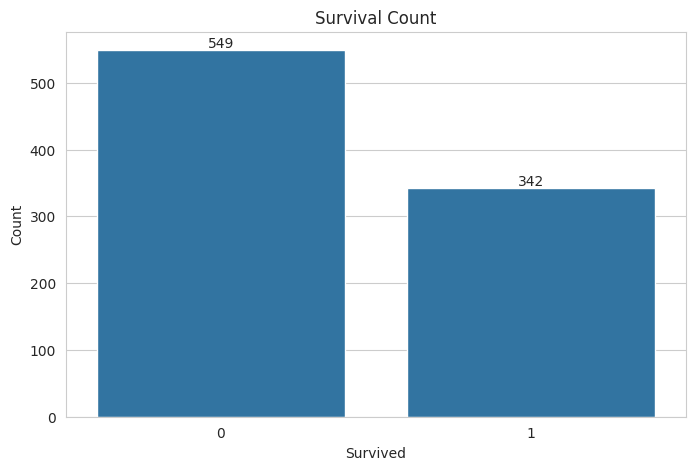

In [45]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

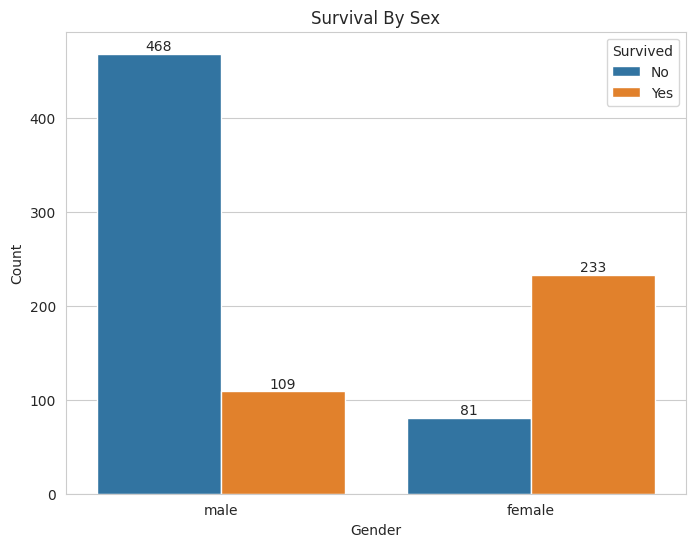

In [54]:
# SURVIVAL BY SEX
plt.figure(figsize=(8,6))
ax = sns.countplot(x='sex', hue='survived' , data=df)
plt.title("Survival By Sex")
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title="Survived", labels=['No','Yes'] )


for container in ax.containers:
    ax.bar_label(container)

plt.show()

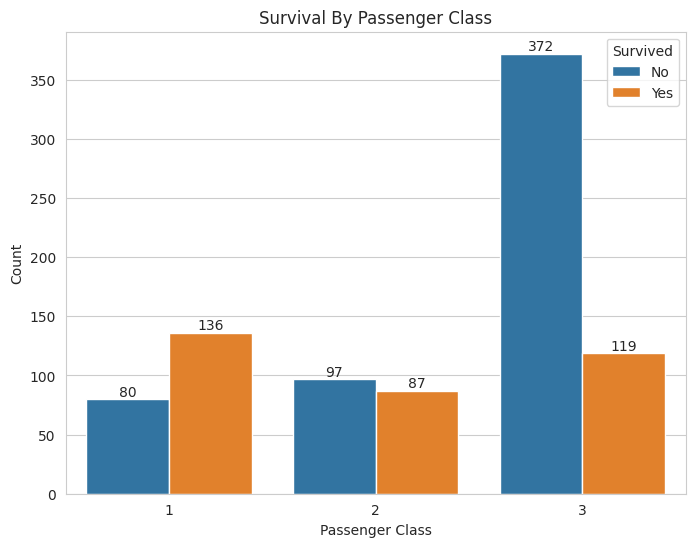

In [53]:
# SURVIVAL BY PASSENGER CLASS
plt.figure(figsize=(8,6))
ax = sns.countplot(x='pclass', hue='survived' , data=df)
plt.title("Survival By Passenger Class")
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title="Survived", labels=['No','Yes'] )

for container in ax.containers:
    ax.bar_label(container)

plt.show()

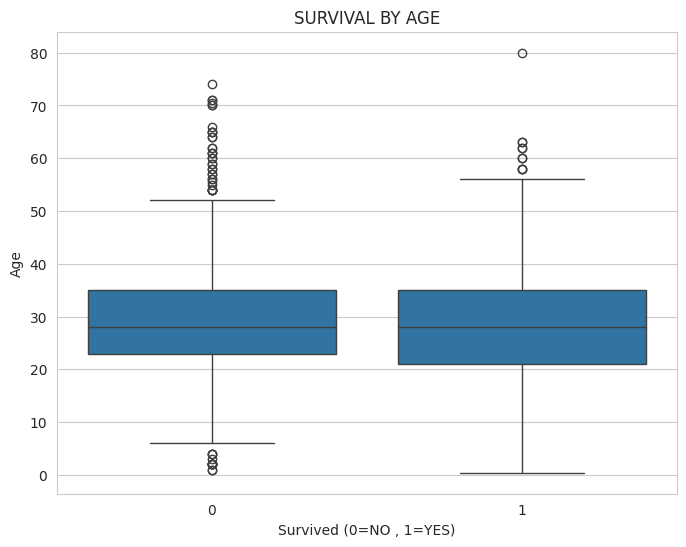

In [57]:
# SURVIVAL BY AGE
plt.figure(figsize=(8,6))
sns.boxplot(x='survived', y='age' , data=df)
plt.title("SURVIVAL BY AGE")
plt.xlabel('Survived (0=NO , 1=YES)')
plt.ylabel('Age')
plt.show()

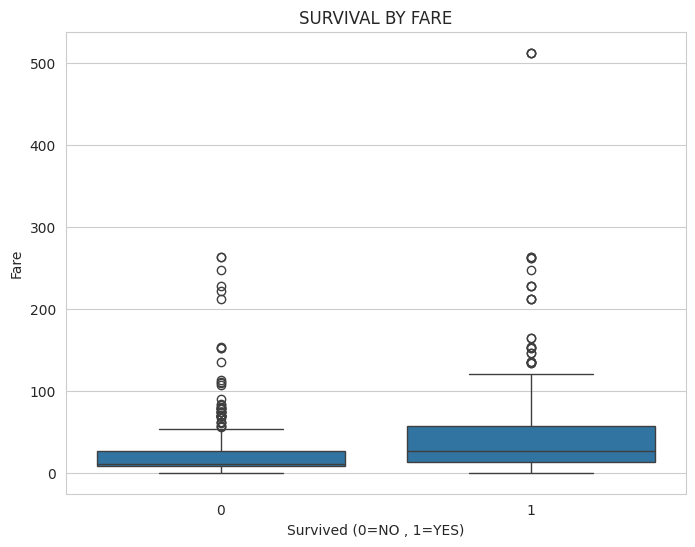

In [59]:
# SURVIVAL BY fare
plt.figure(figsize=(8,6))
sns.boxplot(x='survived', y='fare' , data=df)
plt.title("SURVIVAL BY FARE")
plt.xlabel('Survived (0=NO , 1=YES)')
plt.ylabel('Fare')
plt.show()

### CORRELATION HEATMAP

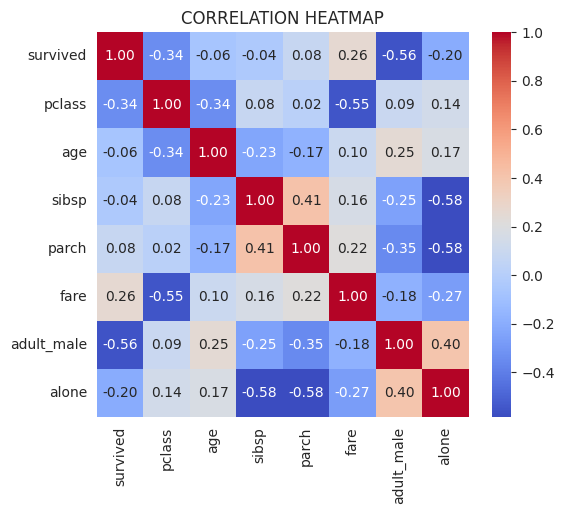

In [61]:
# CORRELATION HEATMAP
corr = df.corr(numeric_only=True)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("CORRELATION HEATMAP")
plt.show()

# Final Key Insights

After performing Exploratory Data Analysis (EDA) on the Titanic dataset, I found the following key insights:

## 1. Survival Distribution
- The target column `survived` is imbalanced.
- More passengers did not survive than survived.

## 2. Gender and Survival
- Female passengers had a much higher survival rate than male passengers.
- Gender appears to be a very important feature.

## 3. Passenger Class and Survival
- 1st class passengers had better survival chances.
- 3rd class passengers had the highest number of deaths.
- Survival decreased from 1st to 3rd class.

## 4. Age and Survival
- Survivors appeared slightly younger overall.
- However, age did not show a very strong separation.

## 5. Fare and Survival
- Survivors generally paid higher fares than non-survivors.
- Fare appears to have a meaningful relationship with survival.

## 6. Important Features
The most meaningful features observed in this analysis were:
- `sex`
- `pclass`
- `fare`
- gender-related encoded feature `adult_male`

# Project Conclusion

In this project, I performed Exploratory Data Analysis (EDA) on the Titanic dataset using Python, NumPy, Pandas, Matplotlib, and Seaborn.

I explored the dataset by:
- understanding its structure
- identifying and handling missing values
- analyzing the target column
- comparing survival patterns across important features
- visualizing numerical and categorical relationships
- identifying key trends and insights

Through this project, I improved my understanding of:
- data cleaning
- target analysis
- feature importance
- categorical and numerical comparison
- correlation analysis
- machine learning preparation

Overall, this project strengthened my foundation in data analysis and helped me prepare for future machine learning work.